### Loading and Displaying an Image

(512, 512)


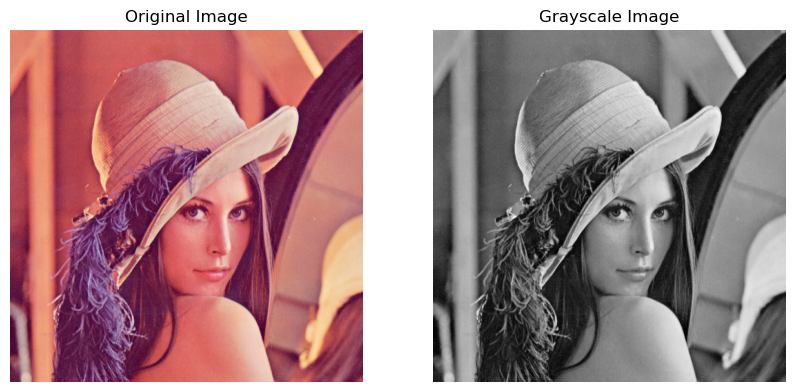

In [116]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load the Lenna image from local file
image = Image.open("Lenna.png")

# Convert to grayscale
gray_image = image.convert("L") # Removes color and keeping only intensity values
gray_np = np.array(gray_image, dtype=np.float32)

print(gray_np.shape)

# Display the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

#### Scaling and Translation

#### Steps
1. Apply contrast adjustment by multiplying a number to each pixel value.
2. Visualize contrast adjustment.
3. Apply brightness adjustment by adding a number to each pixel value, increasing brightness uniformly.
4. Visualize brightness adjustment.

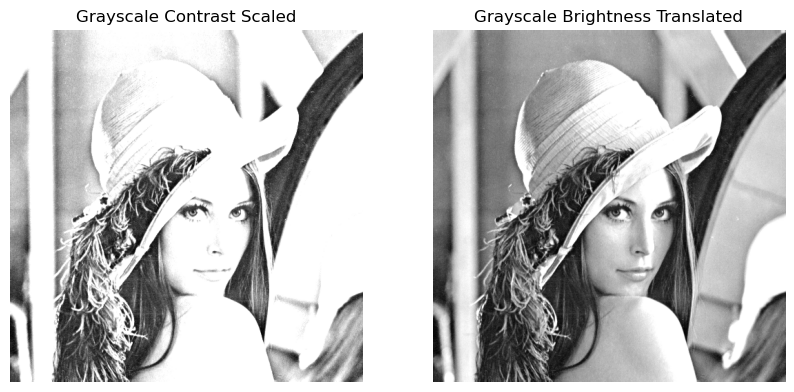

In [117]:
# Perform element-wise operations
# Scaling (adjusting contrast)
scaled_np = gray_np * 2 
scaled_np = np.clip(scaled_np, 0, 255)
scaled_image = Image.fromarray(scaled_np.astype(np.uint8))

# Translation (brightness increase)
translated_np = gray_np + 70 
translated_np = np.clip(translated_np, 0, 255) 
translated_image = Image.fromarray(translated_np.astype(np.uint8))

# Display the images
plt.figure(figsize=(10, 5)) 

plt.subplot(1, 2, 1)
plt.imshow(scaled_image, cmap="gray")
plt.title("Grayscale Contrast Scaled")
plt.axis("off")

plt.subplot(1, 2, 2) 
plt.imshow(translated_image, cmap="gray")
plt.title("Grayscale Brightness Translated")
plt.axis("off")
plt.show()

#### Convolution matrices

#### Steps
1. Define a function to apply a kernel.
2. Applies Sobel X and Y filters then combine results.
3. Visualize result from Sobel edge detection.
4. Define the blur kernel. The kernel values are weighted, with higher values at the center to maintain image structure. Divide by 256 to maintain original brightness.
5. Apply the Gaussian Blur.
6. Visualize result from Gaussian Blur.

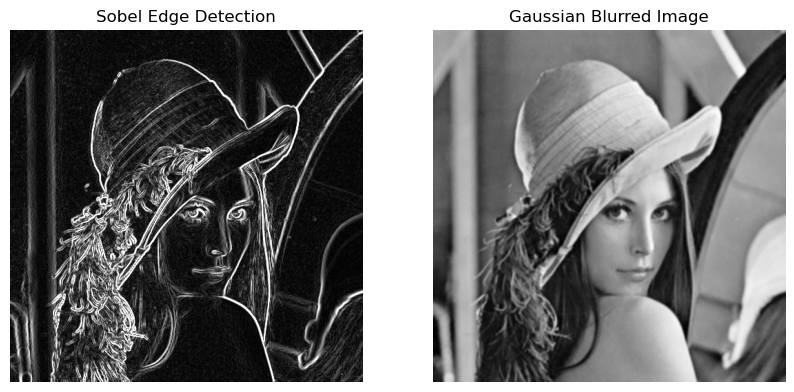

In [120]:
# Apply convolution matrices (kernels)
from scipy.signal import convolve2d

# Function for applying kernels
def apply_kernel(image_np, kernel):
    return convolve2d(image_np, kernel, mode='same', boundary='symm')

# Sobel Edge Detection Kernel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]) # For detecting vertical edges
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]) # For detecting horizontal edges

sobel_x_result = apply_kernel(gray_np, sobel_x)
sobel_y_result = apply_kernel(gray_np, sobel_y)
sobel_edge = np.hypot(sobel_x_result, sobel_y_result) # Combine the results
sobel_edge = np.clip(sobel_edge, 0, 255).astype(np.uint8) 
sobel_edge_image = Image.fromarray(sobel_edge)

# Gaussian Blur Kernel
blur_kernel = np.array([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]]) / 256
blurred_np = apply_kernel(gray_np, blur_kernel)
blurred_np = np.clip(blurred_np, 0, 255)
blurred_image = Image.fromarray(blurred_np.astype(np.uint8))

# Display the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1) 
plt.imshow(sobel_edge, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.subplot(1, 2, 2) 
plt.imshow(blurred_image, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

#### Transformation matrices

#### Steps
1. Rotate image by chosen angle.
2. Visualize rotated image.
3. Apply affine transformation using a linear transformation matrix.
4. Visualize transformed image.

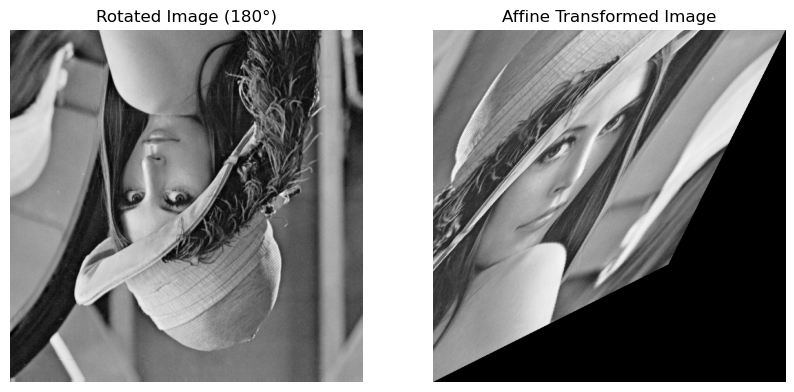

In [121]:
# Rotation transformation
angle = 180 
rotated_image = image.rotate(angle, expand=True)
rotated_gray_image = gray_image.rotate(angle, expand=True)

# Affine transformation (shear)
affine_matrix = np.array([[1, 0.5, 0], [0.5, 1, 0]])
affine_transformed_image = gray_image.transform(gray_image.size, Image.AFFINE, affine_matrix.flatten())

# Display the images
plt.figure(figsize=(10, 5)) 

plt.subplot(1, 2, 1) 
plt.imshow(rotated_gray_image, cmap="gray")
plt.title("Rotated Image (180°)")
plt.axis("off")

plt.subplot(1, 2, 2) 
plt.imshow(affine_transformed_image, cmap="gray")
plt.title("Affine Transformed Image")
plt.axis("off")

plt.show()

#### Matrix Determinants and Inverses

#### Steps
1. Extract a 3x3 submatrix in the image.
2. Compute determinant and inverse.
3. Visualize.

Determinant: 4528.0
Invertable Matrix:
 [[104. 108. 107.]
 [ 96. 100. 103.]
 [ 77.  69.  70.]]
Inverse Matrix:
 [[-0.02363074 -0.0390901   0.09363957]
 [ 0.267447   -0.21179329 -0.09717315]
 [-0.23763251  0.25176677  0.00706714]]


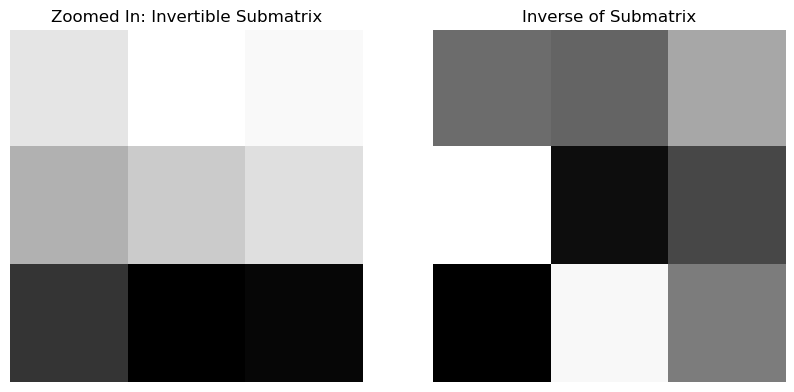

In [127]:
# Select a 3x3 region for demonstration
submatrix = gray_np[255:258,255:258]  

# Compute Determinants and Inverses
determinant = np.linalg.det(submatrix)
inverse_matrix = np.linalg.inv(submatrix)
print(f"Determinant: {determinant}")
print("Invertable Matrix:\n", submatrix)
print("Inverse Matrix:\n", inverse_matrix)

# Display the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(submatrix, cmap="gray", interpolation='nearest')
plt.title("Zoomed In: Invertible Submatrix")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(inverse_matrix, cmap="gray", interpolation='nearest')
plt.title("Inverse of Submatrix")
plt.axis("off")

plt.show()

#### Gaussian Elimination

#### Steps
1. Extract a 3x3 submatrix as the coefficient matrix.
2. Define a right-hand side vector ($b$) for the equation $Ax=b$.
3. Check if the coefficient matrix is invertible.
4. Solve the linear system $Ax=b$.

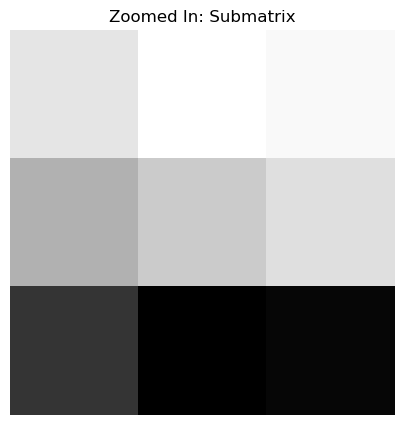

Submatrix chosen:
 [[104. 108. 107.]
 [ 96. 100. 103.]
 [ 77.  69.  70.]]
b vector: [1 2 3]
Solution to system of linear equations: [ 0.17910777 -0.44765901  0.28710247]


In [128]:
# Select a 3x3 coefficient matrix
coeff_matrix = gray_np[255:258,255:258]

# Select b vector
b_vector = np.array([1, 2, 3])  

# Solve a system of linear equations using image data
solution_vector = np.linalg.solve(coeff_matrix, b_vector)

# Display the image
plt.figure(figsize=(5, 5))

plt.imshow(coeff_matrix.astype(np.uint8), cmap="gray", interpolation='nearest')
plt.title("Zoomed In: Submatrix")
plt.axis("off")

plt.show()

print("Submatrix chosen:\n", coeff_matrix)
print("b vector:", b_vector)

# Print solution to system of linear equations
print("Solution to system of linear equations:", solution_vector)

#### Principal Component Analysis (PCA)

#### Steps
1. Apply PCA to reduce dimensionality.
2. Fit PCA and transform the image.
3. Restore the image using inverse transform.
4. Convert the PCA image back to image format.

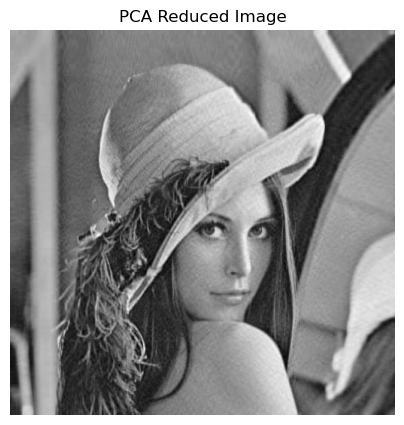

In [132]:
from sklearn.decomposition import PCA

# Perform PCA for dimensionality reduction
pca = PCA(n_components=80)  # Reduce to 80 principal components
flattened_gray = gray_np.reshape(-1, gray_np.shape[1])
pca_transformed = pca.fit_transform(flattened_gray)
pca_restored = pca.inverse_transform(pca_transformed)
pca_image = Image.fromarray(np.clip(pca_restored, 0, 255).astype(np.uint8))

# Display the images
plt.figure(figsize=(5, 5))
plt.imshow(pca_image, cmap="gray")
plt.title("PCA Reduced Image")
plt.axis("off")
plt.show()

#### Markov Chains and Transition Matrices

#### Steps
1. Generate a random probability matrix.
2. Apply the transition probabilities to the image.
3. Convert to an image and visualize.

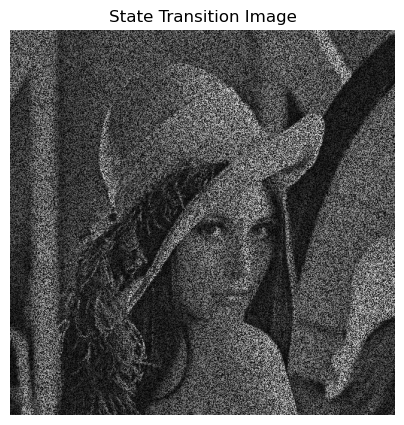

In [134]:
# Simulate state transitions in the image using a probability matrix
prob_matrix = np.random.rand(gray_np.shape[0], gray_np.shape[1])
state_transition = gray_np * prob_matrix 
state_transition = np.clip(state_transition, 0, 255).astype(np.uint8)
state_transition_image = Image.fromarray(state_transition)

# Display figure
plt.figure(figsize=(5, 5))

plt.imshow(state_transition_image, cmap="gray")
plt.title("State Transition Image")
plt.axis("off")
plt.show()

### Eigenvalue and Singular Value Decomposition (SVD) in Image Compression

#### Steps
1. Decompose the image matrix into:

   $U$: left singular vectors (shape: $m \times m$)

   $S$: singular vectors (shape: min($m,n$))

   $Vt$: right singular vectors (shape: $n \times n$)

   Compute the SVD of the image.

2. Reconstruct the image using fewer singular values (k).

3. Convert the reconstructed matrices back to images.

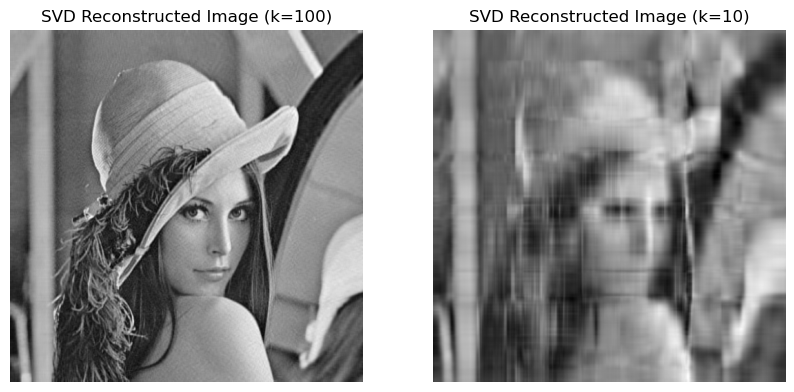

The SVD reconstruction uses (100, 10) singular values.


In [135]:
# Compute SVD and reconstruct image using limited singular values
U, S, Vt = np.linalg.svd(gray_np, full_matrices=False)
k1 = 100 
S_reduced1 = np.zeros((k1, k1))
np.fill_diagonal(S_reduced1, S[:k1])
reconstructed_svd1 = U[:, :k1] @ S_reduced1 @ Vt[:k1, :]
reconstructed_svd_image1 = Image.fromarray(np.clip(reconstructed_svd1, 0, 255).astype(np.uint8))

# Compute SVD and reconstruct image using limited singular values
U, S, Vt = np.linalg.svd(gray_np, full_matrices=False)
k2 = 10 
S_reduced2 = np.zeros((k2, k2))
np.fill_diagonal(S_reduced2, S[:k2])
reconstructed_svd2 = U[:, :k2] @ S_reduced2 @ Vt[:k2, :]
reconstructed_svd_image2 = Image.fromarray(np.clip(reconstructed_svd2, 0, 255).astype(np.uint8))

# Display the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(reconstructed_svd_image1, cmap="gray")
plt.title("SVD Reconstructed Image (k=100)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_svd_image2, cmap="gray")
plt.title("SVD Reconstructed Image (k=10)")
plt.axis("off")

plt.show()

print(f"The SVD reconstruction uses {k1,k2} singular values.")